In [1]:
import xgboost as xgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
homicide_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/database.csv', low_memory=False)
homicide_data.head()

,Record ID,Agency Code,Agency Name,Agency Type,City,State,Year,Month,Incident,Crime Type,...,Victim Ethnicity,Perpetrator Sex,Perpetrator Age,Perpetrator Race,Perpetrator Ethnicity,Relationship,Weapon,Victim Count,Perpetrator Count,Record Source
0,1,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,January,1,Murder or Manslaughter,...,Unknown,Male,15,Native American/Alaska Native,Unknown,Acquaintance,Blunt Object,0,0,FBI
1,2,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,March,1,Murder or Manslaughter,...,Unknown,Male,42,White,Unknown,Acquaintance,Strangulation,0,0,FBI
2,3,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,March,2,Murder or Manslaughter,...,Unknown,Unknown,0,Unknown,Unknown,Unknown,Unknown,0,0,FBI
3,4,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,April,1,Murder or Manslaughter,...,Unknown,Male,42,White,Unknown,Acquaintance,Strangulation,0,0,FBI
4,5,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,April,2,Murder or Manslaughter,...,Unknown,Unknown,0,Unknown,Unknown,Unknown,Unknown,0,1,FBI


In [10]:
#check whether the dataset has any missing values
print('Homicide Data')
missing_values=homicide_data.isnull().sum()
missing_values

Homicide Data


,0
Record ID,0
Agency Code,0
Agency Name,0
Agency Type,0
City,0
State,0
Year,0
Month,0
Incident,0
Crime Type,0


In [11]:
#Dropping Unrelavant columns for the preditions
homicide_data_new=homicide_data.drop(
    ['Record ID', 'Agency Code', 'Agency Name', 'Agency Type', 'Victim Ethnicity','Perpetrator Ethnicity','City','State', 'Year', 'Month','Incident','Record Source'],
    axis=1,
    errors='ignore'
    )
homicide_data_new.head()

,Crime Type,Crime Solved,Victim Sex,Victim Age,Victim Race,Perpetrator Sex,Perpetrator Age,Perpetrator Race,Relationship,Weapon,Victim Count,Perpetrator Count
0,Murder or Manslaughter,Yes,Male,14,Native American/Alaska Native,Male,15,Native American/Alaska Native,Acquaintance,Blunt Object,0,0
1,Murder or Manslaughter,Yes,Male,43,White,Male,42,White,Acquaintance,Strangulation,0,0
2,Murder or Manslaughter,No,Female,30,Native American/Alaska Native,Unknown,0,Unknown,Unknown,Unknown,0,0
3,Murder or Manslaughter,Yes,Male,43,White,Male,42,White,Acquaintance,Strangulation,0,0
4,Murder or Manslaughter,No,Female,30,Native American/Alaska Native,Unknown,0,Unknown,Unknown,Unknown,0,1


In [12]:
# Convert Perpetrator Age to numeric (handle non-numeric cases)
homicide_data_new['Perpetrator Age'] = pd.to_numeric(homicide_data_new['Perpetrator Age'], errors='coerce')

homicide_data_new = homicide_data_new[homicide_data_new["Perpetrator Age"] > 0]
homicide_data_new.head()

,Crime Type,Crime Solved,Victim Sex,Victim Age,Victim Race,Perpetrator Sex,Perpetrator Age,Perpetrator Race,Relationship,Weapon,Victim Count,Perpetrator Count
0,Murder or Manslaughter,Yes,Male,14,Native American/Alaska Native,Male,15.0,Native American/Alaska Native,Acquaintance,Blunt Object,0,0
1,Murder or Manslaughter,Yes,Male,43,White,Male,42.0,White,Acquaintance,Strangulation,0,0
3,Murder or Manslaughter,Yes,Male,43,White,Male,42.0,White,Acquaintance,Strangulation,0,0
5,Murder or Manslaughter,Yes,Male,30,White,Male,36.0,White,Acquaintance,Rifle,0,0
6,Murder or Manslaughter,Yes,Female,42,Native American/Alaska Native,Male,27.0,Black,Wife,Knife,0,0


In [13]:
# Define the age bins and corresponding numeric labels (ordinal encoding)
bins = [0, 18, 35, 50, 65, 100]
labels = [1, 2, 3, 4, 5]

#categorize the 'Perpetrator Age' into age ranges
homicide_data_new['Age Group'] = pd.cut(homicide_data_new['Perpetrator Age'], bins=bins, labels=labels, right=False)
homicide_data_new = homicide_data_new.drop(columns=['Perpetrator Age'])
homicide_data_new.head()

,Crime Type,Crime Solved,Victim Sex,Victim Age,Victim Race,Perpetrator Sex,Perpetrator Race,Relationship,Weapon,Victim Count,Perpetrator Count,Age Group
0,Murder or Manslaughter,Yes,Male,14,Native American/Alaska Native,Male,Native American/Alaska Native,Acquaintance,Blunt Object,0,0,1
1,Murder or Manslaughter,Yes,Male,43,White,Male,White,Acquaintance,Strangulation,0,0,3
3,Murder or Manslaughter,Yes,Male,43,White,Male,White,Acquaintance,Strangulation,0,0,3
5,Murder or Manslaughter,Yes,Male,30,White,Male,White,Acquaintance,Rifle,0,0,3
6,Murder or Manslaughter,Yes,Female,42,Native American/Alaska Native,Male,Black,Wife,Knife,0,0,2


In [14]:
from sklearn.preprocessing import LabelEncoder

# Encode Perpetrator Sex (Binary)
encoder_sex = LabelEncoder()
homicide_data_new['Perpetrator Sex'] = encoder_sex.fit_transform(homicide_data_new['Perpetrator Sex'])

# Encode Perpetrator Race (Multiclass)
encoder_race = LabelEncoder()
homicide_data_new['Perpetrator Race'] = encoder_race.fit_transform(homicide_data_new['Perpetrator Race'])

homicide_data_new.head()


,Crime Type,Crime Solved,Victim Sex,Victim Age,Victim Race,Perpetrator Sex,Perpetrator Race,Relationship,Weapon,Victim Count,Perpetrator Count,Age Group
0,Murder or Manslaughter,Yes,Male,14,Native American/Alaska Native,1,2,Acquaintance,Blunt Object,0,0,1
1,Murder or Manslaughter,Yes,Male,43,White,1,4,Acquaintance,Strangulation,0,0,3
3,Murder or Manslaughter,Yes,Male,43,White,1,4,Acquaintance,Strangulation,0,0,3
5,Murder or Manslaughter,Yes,Male,30,White,1,4,Acquaintance,Rifle,0,0,3
6,Murder or Manslaughter,Yes,Female,42,Native American/Alaska Native,1,1,Wife,Knife,0,0,2


In [15]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Label Encoding for Binary Columns
binary_cols = ['Crime Solved', 'Victim Sex', 'Perpetrator Sex']
for col in binary_cols:
    homicide_data_new[col] = LabelEncoder().fit_transform(homicide_data_new[col])

# One-Hot Encoding for Multiclass Categorical Columns
multi_cols = ['Crime Type', 'Victim Race', 'Relationship', 'Weapon']
homicide_data_new = pd.get_dummies(homicide_data_new, columns=multi_cols, drop_first=True)

homicide_data_new.head()

,Crime Solved,Victim Sex,Victim Age,Perpetrator Sex,Perpetrator Race,Victim Count,Perpetrator Count,Age Group,Crime Type_Murder or Manslaughter,Victim Race_Black,...,Weapon_Firearm,Weapon_Gun,Weapon_Handgun,Weapon_Knife,Weapon_Poison,Weapon_Rifle,Weapon_Shotgun,Weapon_Strangulation,Weapon_Suffocation,Weapon_Unknown
0,1,1,14,1,2,0,0,1,True,False,...,False,False,False,False,False,False,False,False,False,False
1,1,1,43,1,4,0,0,3,True,False,...,False,False,False,False,False,False,False,True,False,False
3,1,1,43,1,4,0,0,3,True,False,...,False,False,False,False,False,False,False,True,False,False
5,1,1,30,1,4,0,0,3,True,False,...,False,False,False,False,False,True,False,False,False,False
6,1,0,42,1,1,0,0,2,True,False,...,False,False,False,True,False,False,False,False,False,False


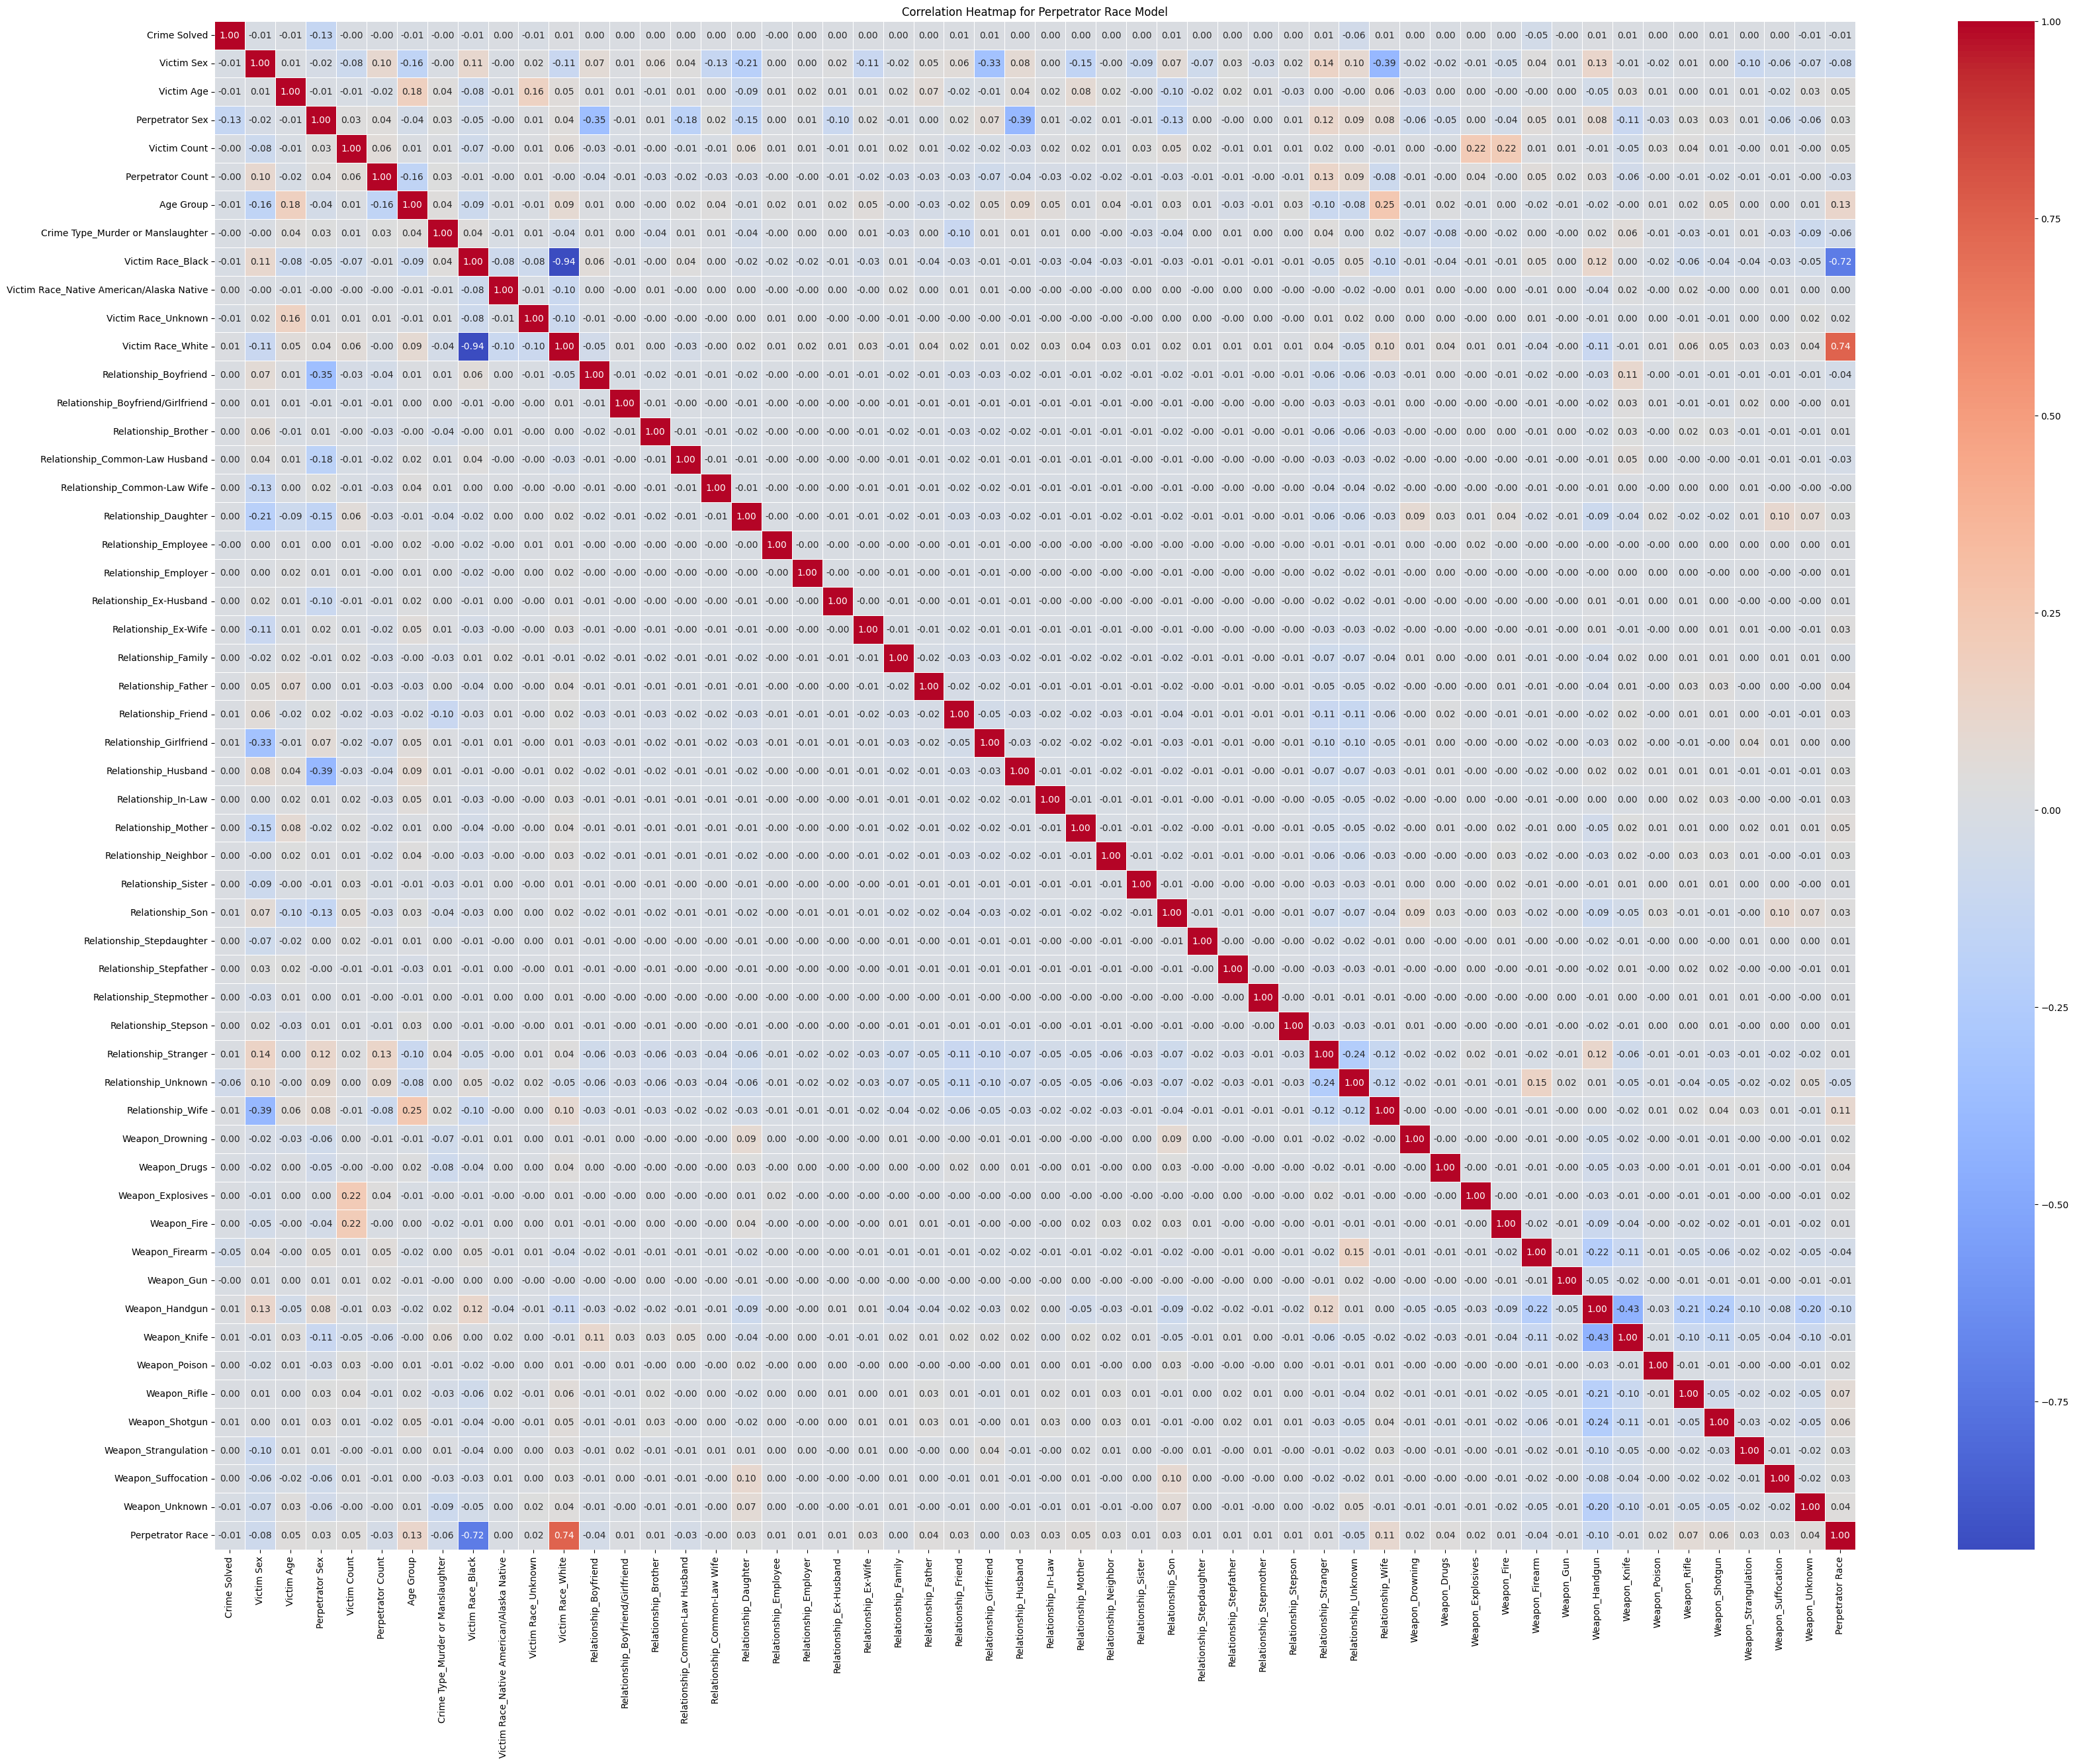

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import chi2

# Feature Selection
def perform_feature_selection(df, target_column):
    # Drop target variable from features
    X = df.drop(["Perpetrator Race"], axis=1)
    y = df[target_column]

    # Scale features
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)

    # Perform Chi-Square test
    chi2_scores, p_values = chi2(X_scaled, y)

    # Select features with p-value < 0.05
    selected_features = X.columns[p_values < 0.05].tolist()

    return selected_features

# Apply feature selection for each target variable
selected_features_race = perform_feature_selection(homicide_data_new, "Perpetrator Race")

# Heatmap Visualization
def plot_correlation_heatmap(df, selected_features, target_column, title):
    features = df[selected_features].copy()  # Explicitly create a copy
    features.loc[:, target_column] = df[target_column]  # Use .loc to avoid the warning

    # Compute correlation matrix
    corr_matrix = features.corr()

    # Plot heatmap
    plt.figure(figsize=(40, 30))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
    plt.title(title)
    plt.show()


# Plot heatmaps for each model
plot_correlation_heatmap(homicide_data_new, selected_features_race, "Perpetrator Race", "Correlation Heatmap for Perpetrator Race Model")

In [17]:
from sklearn.feature_selection import mutual_info_classif

# Define features and target
X = homicide_data_new.drop(columns=['Perpetrator Race'])  # Features
y = homicide_data_new['Perpetrator Race']  # Target

# Compute Mutual Information
mi_scores = mutual_info_classif(X, y, discrete_features=True)
mi_scores_df = pd.DataFrame({'Feature': X.columns, 'MI Score': mi_scores})
mi_scores_df = mi_scores_df.sort_values(by='MI Score', ascending=False)

# Display top 10 features
mi_scores_df.head(10)


,Feature,MI Score
8,Victim Race_Black,0.332234
11,Victim Race_White,0.317283
9,Victim Race_Native American/Alaska Native,0.018619
10,Victim Race_Unknown,0.009622
6,Age Group,0.009610
2,Victim Age,0.008913
3,Perpetrator Sex,0.006852
38,Relationship_Wife,0.006780
46,Weapon_Handgun,0.006754
0,Crime Solved,0.006132


In [18]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Select the best features based on MI scores
selected_features = ['Victim Race_Black', 'Victim Race_White','Age Group','Perpetrator Sex']

# Define X (features) and y (target)
X = homicide_data_new[selected_features]
y = homicide_data_new['Perpetrator Race']  # Target variable

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE to balance classes
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Normalize numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

# Train XGBoost Classifier with tuned hyperparameters
model = XGBClassifier(
    objective='multi:softmax',
    num_class=len(y.unique()),
    eval_metric='mlogloss',
    learning_rate=0.1,  # Tuned learning rate
    n_estimators=200,  # More trees
    max_depth=6,  # Optimal depth for capturing interactions
    subsample=0.8,  # Prevents overfitting
    colsample_bytree=0.8,  # Uses only 80% of features per tree
    random_state=42
)

model.fit(X_train_scaled, y_train_resampled)

# Make Predictions
y_pred = model.predict(X_test_scaled)

# Evaluate Model Performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Model Accuracy: 0.8573

Classification Report:
               precision    recall  f1-score   support

           0       0.28      0.59      0.38      1168
           1       0.91      0.84      0.87     39650
           2       0.24      0.08      0.12       706
           3       0.91      0.16      0.27       708
           4       0.85      0.90      0.88     42194

    accuracy                           0.86     84426
   macro avg       0.64      0.51      0.50     84426
weighted avg       0.86      0.86      0.86     84426

